In [ ]:
## MLCB Assignment 1 - Task 2: Baseline Models

%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import sys
import os
sys.path.append(os.path.abspath('..'))

from src.functions import (load_data, get_feature_matrix_target_and_features, 
                           split_stratified_data, build_preprocessor,
                           build_num_preprocessor, build_cat_preprocessor, 
                           evaluate_model_bootstraping, print_evaluation_results,
                           build_results_table, get_comparison_boxplot)

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, ElasticNet, BayesianRidge
from sklearn.svm import SVR

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
# Load the data and feature matrices
df_development = load_data('../data/development_data.csv')
target_column = "age" 
first_column_name = df_development.columns[0]
df_development.set_index(first_column_name, inplace=True)

X, y, cpg_features, cat_features = get_feature_matrix_target_and_features(df_development, target_column)

# Split the data into training and validation sets (combined features)
X_train, X_val, y_train, y_val = split_stratified_data(X, y, n_bins=5, test_size=0.2, random_state=42)

# numerical and categorical feature matrices
X_train_num, X_val_num = X_train[cpg_features], X_val[cpg_features]
X_train_cat, X_val_cat = X_train[cat_features], X_val[cat_features]

# load the preprocessors from functions.py
my_preprocessor = build_preprocessor(cpg_features, cat_features)
num_preprocessor = build_num_preprocessor()
cat_preprocessor = build_cat_preprocessor()

In [5]:
# --- OLS Linear Regression models ---

# Model 1: OLS Linear Regression with categorical features only
ols_cat_pipe = Pipeline([
    ('preprocessor', cat_preprocessor),
    ('model', LinearRegression())
])
ols_cat_pipe.fit(X_train_cat, y_train)
y_pred_cat = ols_cat_pipe.predict(X_val_cat)
ols_cat_metrics, ols_cat_dict = evaluate_model_bootstraping(y_val, y_pred_cat, n_bootstraps=1000, random_state=42)
print_evaluation_results("OLS Linear Regression (Categorical Features Only)", ols_cat_metrics)

# Model 2: OLS Linear Regression with numerical features only
ols_num_pipe = Pipeline([
    ('preprocessor', num_preprocessor),
    ('model', LinearRegression())
])
ols_num_pipe.fit(X_train_num, y_train)
y_pred_num = ols_num_pipe.predict(X_val_num)
ols_num_metrics, ols_num_dict = evaluate_model_bootstraping(y_val, y_pred_num, n_bootstraps=1000, random_state=42)
print_evaluation_results("OLS Linear Regression (Numerical Features Only)", ols_num_metrics)

# Model 3: OLS Linear Regression with ALL features
ols_all_pipe = Pipeline([
    ('preprocessor', my_preprocessor),
    ('model', LinearRegression())
])
ols_all_pipe.fit(X_train, y_train)
y_pred_all = ols_all_pipe.predict(X_val)
ols_metrics, ols_dict = evaluate_model_bootstraping(y_val, y_pred_all, n_bootstraps=1000, random_state=42)
print_evaluation_results("OLS Linear Regression (Combined Features)", ols_metrics)


OLS Linear Regression (Categorical Features Only) Results:
RMSE: 12.8174 (95% CI: [10.9469, 14.9028])
MAE: 10.3067 (95% CI: [8.8008, 11.8238])
R2: 0.2176 (95% CI: [0.0753, 0.3498])
PEARSON: 0.4865 (95% CI: [0.3302, 0.6289])

OLS Linear Regression (Numerical Features Only) Results:
RMSE: 7.1472 (95% CI: [4.9444, 9.4633])
MAE: 4.6312 (95% CI: [3.6033, 5.8299])
R2: 0.7471 (95% CI: [0.5333, 0.8844])
PEARSON: 0.8979 (95% CI: [0.8304, 0.9475])

OLS Linear Regression (Combined Features) Results:
RMSE: 7.1184 (95% CI: [4.9402, 9.4414])
MAE: 4.6190 (95% CI: [3.5899, 5.7970])
R2: 0.7491 (95% CI: [0.5316, 0.8853])
PEARSON: 0.8984 (95% CI: [0.8298, 0.9481])


# OLS baseline models

Clear conclusion: Most of the predictive power comes from the CpG features (biological signal), 
while the categorical features (metadata) contribute very little to the model's performance.

- **Metadata-only** (sex + ethnicity): RMSE=12.82, R²=0.22 —> very weak predictive signal
- **CpG-only**: RMSE=7.15, R²=0.75 —> strong biological signal
- **Combined** (CpG + metadata): RMSE=7.12, R²=0.75 —> virtually identical to CpG-only

The negligible improvement of Combined vs CpG-only (RMSE: 7.12 vs 7.15, ΔR²=0.002) 
confirms that sex and ethnicity add no independent predictive signal once CpG methylation 
is included. The CpG-only model will serve as the OLS baseline floor for subsequent tasks.

In [6]:
# --- Three additional baseline models ---

# Model 4: ElasticNet Regression
elastic_net_pipe = Pipeline([
    ('preprocessor', num_preprocessor),
    ('model', ElasticNet())
])
elastic_net_pipe.fit(X_train_num, y_train)
y_pred_elastic_net = elastic_net_pipe.predict(X_val_num)
elastic_net_metrics, elastic_net_dict = evaluate_model_bootstraping(y_val, y_pred_elastic_net, n_bootstraps=1000, random_state=42)
print_evaluation_results("ElasticNet Regression", elastic_net_metrics)

# Model 5: Support Vector Regression (SVR)
svr_pipe = Pipeline([
    ('preprocessor', num_preprocessor),
    ('model', SVR())
])
svr_pipe.fit(X_train_num, y_train)
y_pred_svr = svr_pipe.predict(X_val_num)
svr_metrics, svr_dict = evaluate_model_bootstraping(y_val, y_pred_svr, n_bootstraps=1000, random_state=42)
print_evaluation_results("Support Vector Regression (SVR)", svr_metrics)

# Model 6: Bayesian Ridge Regression
bayesian_ridge_pipe = Pipeline([
    ('preprocessor', num_preprocessor),
    ('model', BayesianRidge())
])
bayesian_ridge_pipe.fit(X_train_num, y_train)
y_pred_bayesian_ridge = bayesian_ridge_pipe.predict(X_val_num)
bayesian_ridge_metrics, bayesian_ridge_dict = evaluate_model_bootstraping(y_val, y_pred_bayesian_ridge, n_bootstraps=1000, random_state=42)
print_evaluation_results("Bayesian Ridge Regression", bayesian_ridge_metrics)


ElasticNet Regression Results:
RMSE: 5.8259 (95% CI: [4.6115, 7.2873])
MAE: 4.2613 (95% CI: [3.4801, 5.0534])
R2: 0.8341 (95% CI: [0.7240, 0.9040])
PEARSON: 0.9163 (95% CI: [0.8608, 0.9516])

Support Vector Regression (SVR) Results:
RMSE: 9.4965 (95% CI: [7.8897, 11.2905])
MAE: 7.3301 (95% CI: [6.1561, 8.6786])
R2: 0.5713 (95% CI: [0.4960, 0.6474])
PEARSON: 0.8045 (95% CI: [0.7499, 0.8587])

Bayesian Ridge Regression Results:
RMSE: 6.3089 (95% CI: [4.5641, 8.4635])
MAE: 4.1086 (95% CI: [3.2040, 5.0813])
R2: 0.8028 (95% CI: [0.6313, 0.9071])
PEARSON: 0.9125 (95% CI: [0.8464, 0.9545])


## Model Comparison vs OLS Baseline (CpG-only RMSE=7.15)

- **ElasticNet**: RMSE=5.83 ✓ beats OLS by 1.32 years —> L1+L2 regularization 
  effectively handles the high-dimensional feature space (1000 CpGs), reducing 
  overfitting compared to plain OLS.
- **BayesianRidge**: RMSE=6.31 ✓ beats OLS by 0.84 years —> automatic relevance 
  determination provides implicit regularization, though less aggressively than ElasticNet.
- **SVR**: RMSE=9.50 ✗ does NOT beat OLS at default hyperparameters (C=1.0). 
  The default C=1.0 is too constrained for 1000-dimensional input, causing underfitting. 
  SVR is retained for Task 4 where tuning C up to 500 is expected to recover performance.

ElasticNet is the strongest baseline, followed by BayesianRidge. Both justify inclusion 
in subsequent feature selection and tuning tasks.

In [ ]:
# Note: the same num_preprocessor instance is reused across pipelines since
# the input (X_train_num) is identical for all models. In cases where inputs
# differ per model, a fresh preprocessor instance should be used for each pipeline.
# If we had different inputs per model, we would create separate preprocessor instances for 
# each pipeline.
# ols_num_pipe = Pipeline([('preprocessor', build_num_preprocessor()), ('model', LinearRegression())])
# elastic_net_pipe = Pipeline([('preprocessor', build_num_preprocessor()), ('model', ElasticNet())])
# svr_pipe = Pipeline([('preprocessor', build_num_preprocessor()), ('model', SVR())])

In [7]:
# Build results tables for OLS models and additional baseline models
ols_table = build_results_table({
    'OLS (Categorical)': ols_cat_metrics,
    'OLS (CpG only)':    ols_num_metrics,
    'OLS (Combined)':    ols_metrics,
}, stage='Baseline')

models_table = build_results_table({
    'ElasticNet':    elastic_net_metrics,
    'SVR':           svr_metrics,
    'BayesianRidge': bayesian_ridge_metrics,
}, stage='Baseline')

display(ols_table)
display(models_table)

,Stage,RMSE (mean),95% CI,MAE,R²,Pearson r
Model,,,,,,
OLS (Categorical),Baseline,12.8174,"[10.9469, 14.9028]",10.3067,0.2176,0.4865
OLS (CpG only),Baseline,7.1472,"[4.9444, 9.4633]",4.6312,0.7471,0.8979
OLS (Combined),Baseline,7.1184,"[4.9402, 9.4414]",4.6190,0.7491,0.8984


,Stage,RMSE (mean),95% CI,MAE,R²,Pearson r
Model,,,,,,
ElasticNet,Baseline,5.8259,"[4.6115, 7.2873]",4.2613,0.8341,0.9163
SVR,Baseline,9.4965,"[7.8897, 11.2905]",7.3301,0.5713,0.8045
BayesianRidge,Baseline,6.3089,"[4.5641, 8.4635]",4.1086,0.8028,0.9125


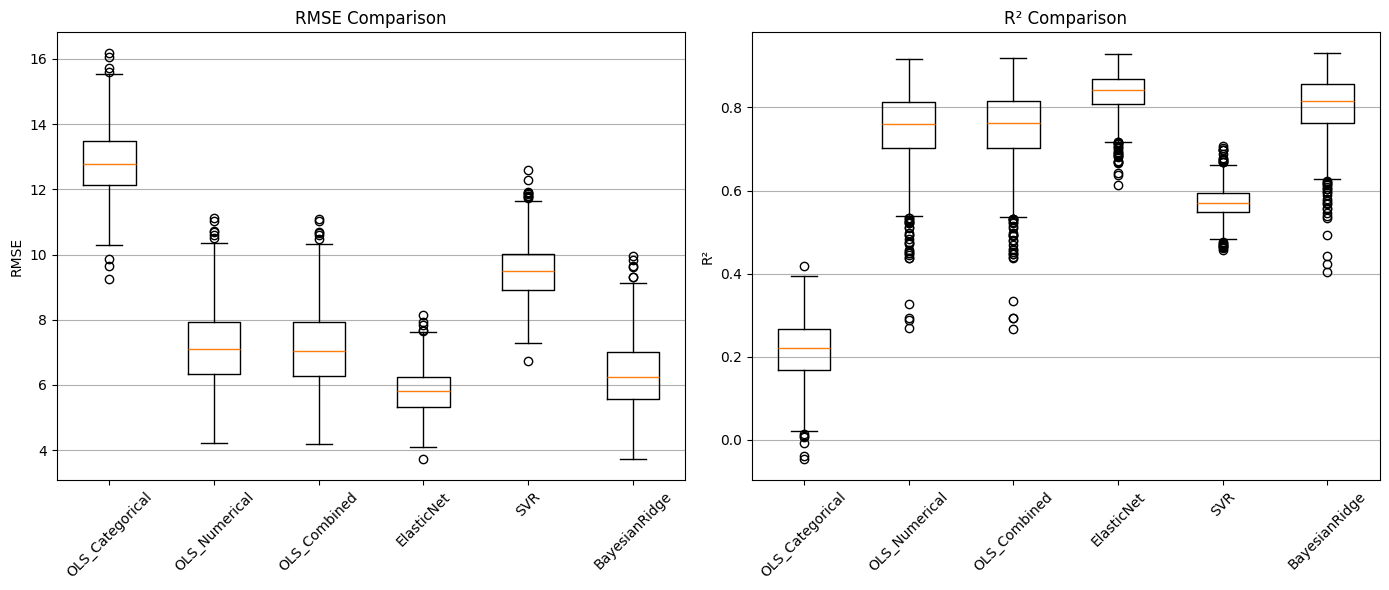

In [9]:
# --- Boxplots ---
all_models_dicts = {
    "OLS_Categorical": ols_cat_dict,
    "OLS_Numerical": ols_num_dict,
    "OLS_Combined": ols_dict,
    "ElasticNet": elastic_net_dict,
    "SVR": svr_dict,
    "BayesianRidge": bayesian_ridge_dict,
}

get_comparison_boxplot(all_models_dicts, save_path='../figures/baseline_models_comparison_boxplot.png')